<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan4_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 4
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Langkah 1: Memuat dataset Iris bawaan dari Seaborn
df = sns.load_dataset('iris')
print('=== Info Ukuran & Tipe Data ===')
print('Shape:', df.shape)
print(df.dtypes)
print('\n=== 5 Baris Pertama Data ===')
print(df.head())
print('\n=== Ringkasan Statistik Dasar ===')
print(df.describe().round(3))

# Langkah 2: Statistik Deskriptif Lengkap untuk Kolom Angka
print('\n' + '='*50 + '\n=== Statistik Deskriptif Detail ===')
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n--- Kolom: {col_name} ---')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')

=== Info Ukuran & Tipe Data ===
Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== 5 Baris Pertama Data ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Ringkasan Statistik Dasar ===
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%      

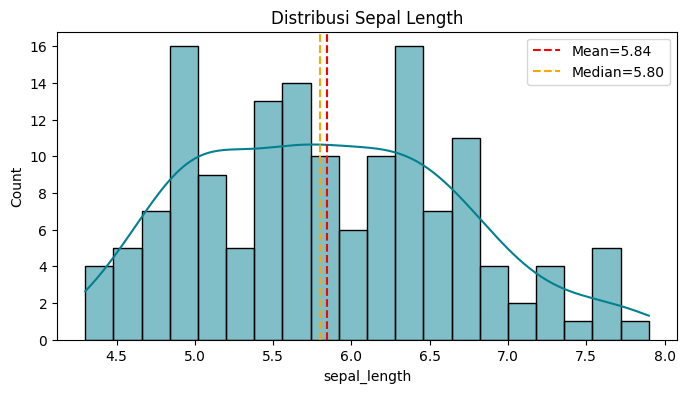

In [2]:
# Langkah 3: Membuat grafik distribusi untuk kolom sepal_length
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

# Menambahkan garis rata-rata (mean) dan nilai tengah (median)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

/tmp/ipykernel_4453/3557187452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4453/3557187452.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


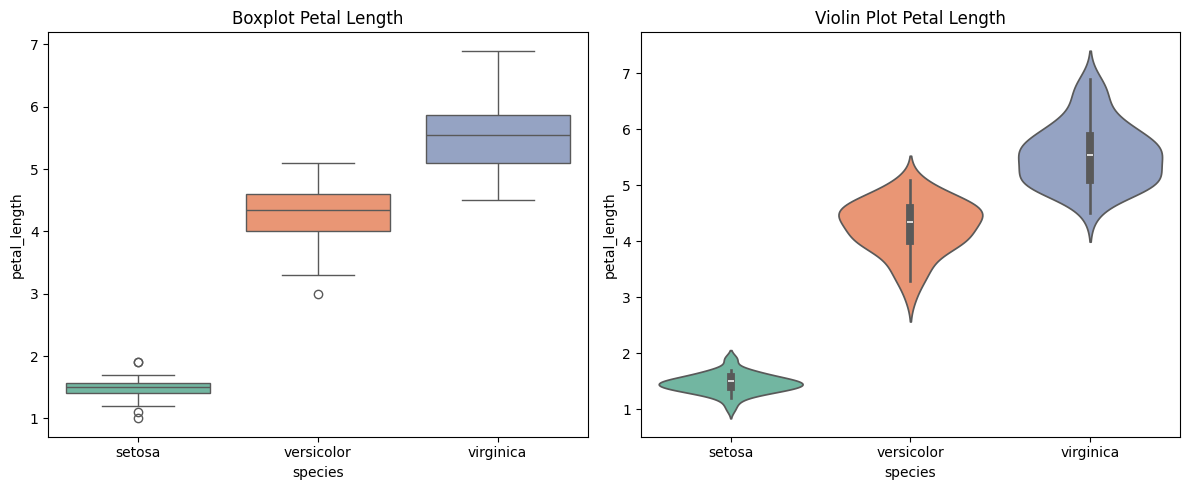

In [3]:
# Langkah 4: Membuat grafik Boxplot dan Violin Plot untuk membandingkan sebaran antar spesies
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafik Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    # Menghapus duplikasi pemetaan warna agar parameter hue bekerja dengan baik
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Boxplot Petal Length')

# Grafik Violin Plot
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

=== Matriks Korelasi Pearson ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi ditemukan pada pasangan: ('petal_width', 'petal_length') = 0.963




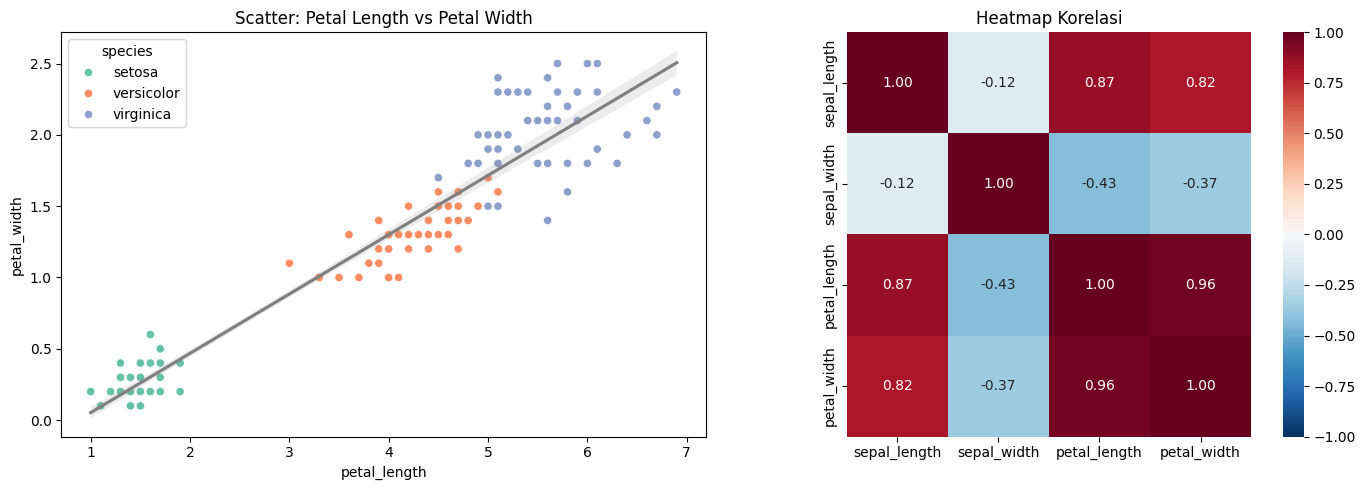

In [4]:
# Langkah 5: Menghitung hubungan (korelasi) antar kolom angka
corr = df.drop('species', axis=1).corr(method='pearson')
print("=== Matriks Korelasi Pearson ===")
print(corr.round(3))

# Mencari pasangan fitur dengan hubungan tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'\nKorelasi tertinggi ditemukan pada pasangan: {max_pair} = {corr.loc[max_pair]:.3f}')

print('\n' + '='*50 + '\n')

# Langkah 6: Membuat Scatter Plot Hubungan dan Heatmap Korelasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

# Heatmap Korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

## Kesimpulan

* **Apa yang Dipelajari:** Di pertemuan keempat ini, saya belajar cara melakukan analisis dasar pada sekumpulan data menggunakan grafik dan perhitungan statistik (EDA). Saya mempraktikkan cara menghitung nilai rata-rata, nilai tengah, kemiringan grafik data, serta membuat berbagai macam grafik seperti diagram batang distribusi (histogram), kotak sebaran data (boxplot), diagram lekukan bentuk data (violin plot), hingga grafik titik hubungan antarvariabel (scatter plot dan heatmap).
* **Temuan Utama:** Melalui bantuan grafik, membaca karakteristik data yang banyak ternyata menjadi jauh lebih mudah. Pada data bunga Iris ini, saya menemukan bahwa ukuran panjang dan lebar kelopak bunga (*petal_length* dan *petal_width*) memiliki hubungan yang sangat kuat dan searah; artinya jika kelopaknya makin panjang, maka lebarnya pasti makin besar. Selain itu, grafik boxplot berhasil menunjukkan dengan jelas bahwa jenis bunga Iris Setosa memiliki ukuran kelopak yang jauh lebih kecil dan mengelompok terpisah dibandingkan jenis Versicolor dan Virginica.
* **Keterbatasan / Pertanyaan yang Muncul:** * *Keterbatasan:* Analisis data di atas baru membandingkan hubungan antara dua kolom data saja secara bergantian, belum bisa memperlihatkan bagaimana semua kolom digabungkan sekaligus untuk menebak jenis spesiesnya secara otomatis.
  * *Pertanyaan:* Bagaimana cara memanfaatkan temuan perbedaan ukuran kelopak ini ke dalam sebuah rumus matematika atau kecerdasan buatan, agar program komputer nantinya bisa menebak sendiri nama spesies bunga Iris yang baru diukur?